# Notebook extracting vortex inducex vibration (VIV) data


In [1]:
import os
os.environ["JAX_PLATFORMS"] = "cpu"  # diffrax callbacks (error_if) not supported on MPS

import numpy as np
import scipy.io
from pathlib import Path
import matplotlib.pyplot as plt


# Directory containing the .mat files
data_dir = Path('NDP38m_test_data')
output_dir = Path('NDP38m_extracted')
output_dir.mkdir(exist_ok=True)

mat_files = sorted(data_dir.glob('DISPL*.mat'))
print(f"Found {len(mat_files)} .mat files: {[p.name for p in mat_files]}")

for mat_path in mat_files:
    print(f"\nLoading {mat_path}")
    mat_data = scipy.io.loadmat(mat_path)
    # Filter out MATLAB meta keys
    data_keys = [k for k in mat_data.keys() if not k.startswith('__')]
    print(f"  Variables: {data_keys}")

    if not data_keys:
        print("  No data variables found, skipping")
        continue

    # Heuristic: pick the largest array-like object as the main data
    candidate = None
    max_size = 0
    for k in data_keys:
        v = mat_data[k]
        try:
            size = np.prod(v.shape)
        except Exception:
            size = 0
        if size > max_size:
            max_size = size
            candidate = k

    if candidate is None:
        print("  No suitable array found, skipping")
        continue

    main_array = mat_data[candidate]
    out_name = output_dir / (mat_path.stem + f"_{candidate}.npz")
    # Save using numpy compressed format
    np.savez_compressed(out_name, **{candidate: main_array})
    print(f"  Saved main variable '{candidate}' to {out_name} with shape {main_array.shape} and dtype {main_array.dtype}")

print('\nExtraction complete.')


Found 4 .mat files: ['DISPL2040.mat', 'DISPL2100.mat', 'DISPL2160.mat', 'DISPL2220.mat']

Loading NDP38m_test_data/DISPL2040.mat
  Variables: ['DISPLIL', 'DISPLCF']
  Saved main variable 'DISPLIL' to NDP38m_extracted/DISPL2040_DISPLIL.npz with shape (200, 35000) and dtype >f8

Loading NDP38m_test_data/DISPL2100.mat
  Variables: ['DISPLIL', 'DISPLCF']
  Saved main variable 'DISPLIL' to NDP38m_extracted/DISPL2100_DISPLIL.npz with shape (200, 24946) and dtype >f8

Loading NDP38m_test_data/DISPL2160.mat
  Variables: ['DISPLIL', 'DISPLCF']
  Saved main variable 'DISPLIL' to NDP38m_extracted/DISPL2160_DISPLIL.npz with shape (200, 14727) and dtype >f8

Loading NDP38m_test_data/DISPL2220.mat
  Variables: ['DISPLIL', 'DISPLCF']
  Saved main variable 'DISPLIL' to NDP38m_extracted/DISPL2220_DISPLIL.npz with shape (200, 9036) and dtype >f8

Extraction complete.


## Plot of all dataframes showing the time propagation across all channels

Plotting DISPL2040_DISPLCF.csv


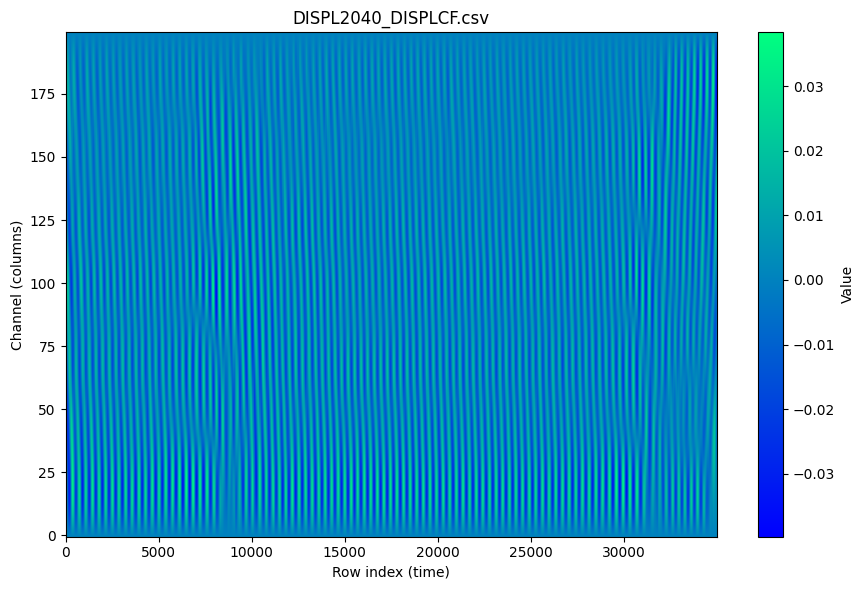

In [2]:
csv_out = Path('NDP38m_extracted_csv')
csv_out.mkdir(exist_ok=True)
import pandas as pd
for csv_path in sorted(csv_out.glob('*.csv')):
    print(f"Plotting {csv_path.name}")
    try:
        df = pd.read_csv(csv_path).to_numpy()
    except Exception as e:
        print(f"  Failed to read {csv_path.name}: {e}")
        continue

    plt.figure(figsize=(9, 6))
    plt.title(csv_path.name)
    plt.xlabel('Row index (time)')
    plt.ylabel('Channel (columns)')
    plt.imshow(df[:, :], aspect='auto', cmap='winter', origin='lower', interpolation='bilinear')
    plt.colorbar(label='Value')
    plt.tight_layout()
    plt.show()
    break


In [12]:
csv_files = sorted(csv_out.glob('*.csv'))
print(f'csv_files.shape: {len(csv_files)}')
_df_cf = None
_df_il = None
def extract_dataframe(path_cf, path_il, stride = 4):
    cf_loc = pd.read_csv(path_cf).to_numpy()[:, ::stride].T
    il_loc = pd.read_csv(path_il).to_numpy()[:, ::stride].T
    min_measurement = np.min([cf_loc.shape[0], il_loc.shape[0]])
    
    _df_cf = cf_loc[:min_measurement]
    print(f'_df_cf: {_df_cf.shape}')
    
    _df_il = il_loc[:min_measurement]

    print(f'_df_il: {_df_il.shape}')
    return _df_cf, _df_il

_df_cf, _df_il = extract_dataframe(csv_files[1],csv_files[2], stride = 1)

Nt, Nx = _df_cf.shape

csv_files.shape: 8
_df_cf: (24946, 192)
_df_il: (24946, 200)


Reconstruction of inline: 5.691786018197087e-13
Reconstuction of cross flow: 11.208810806274414


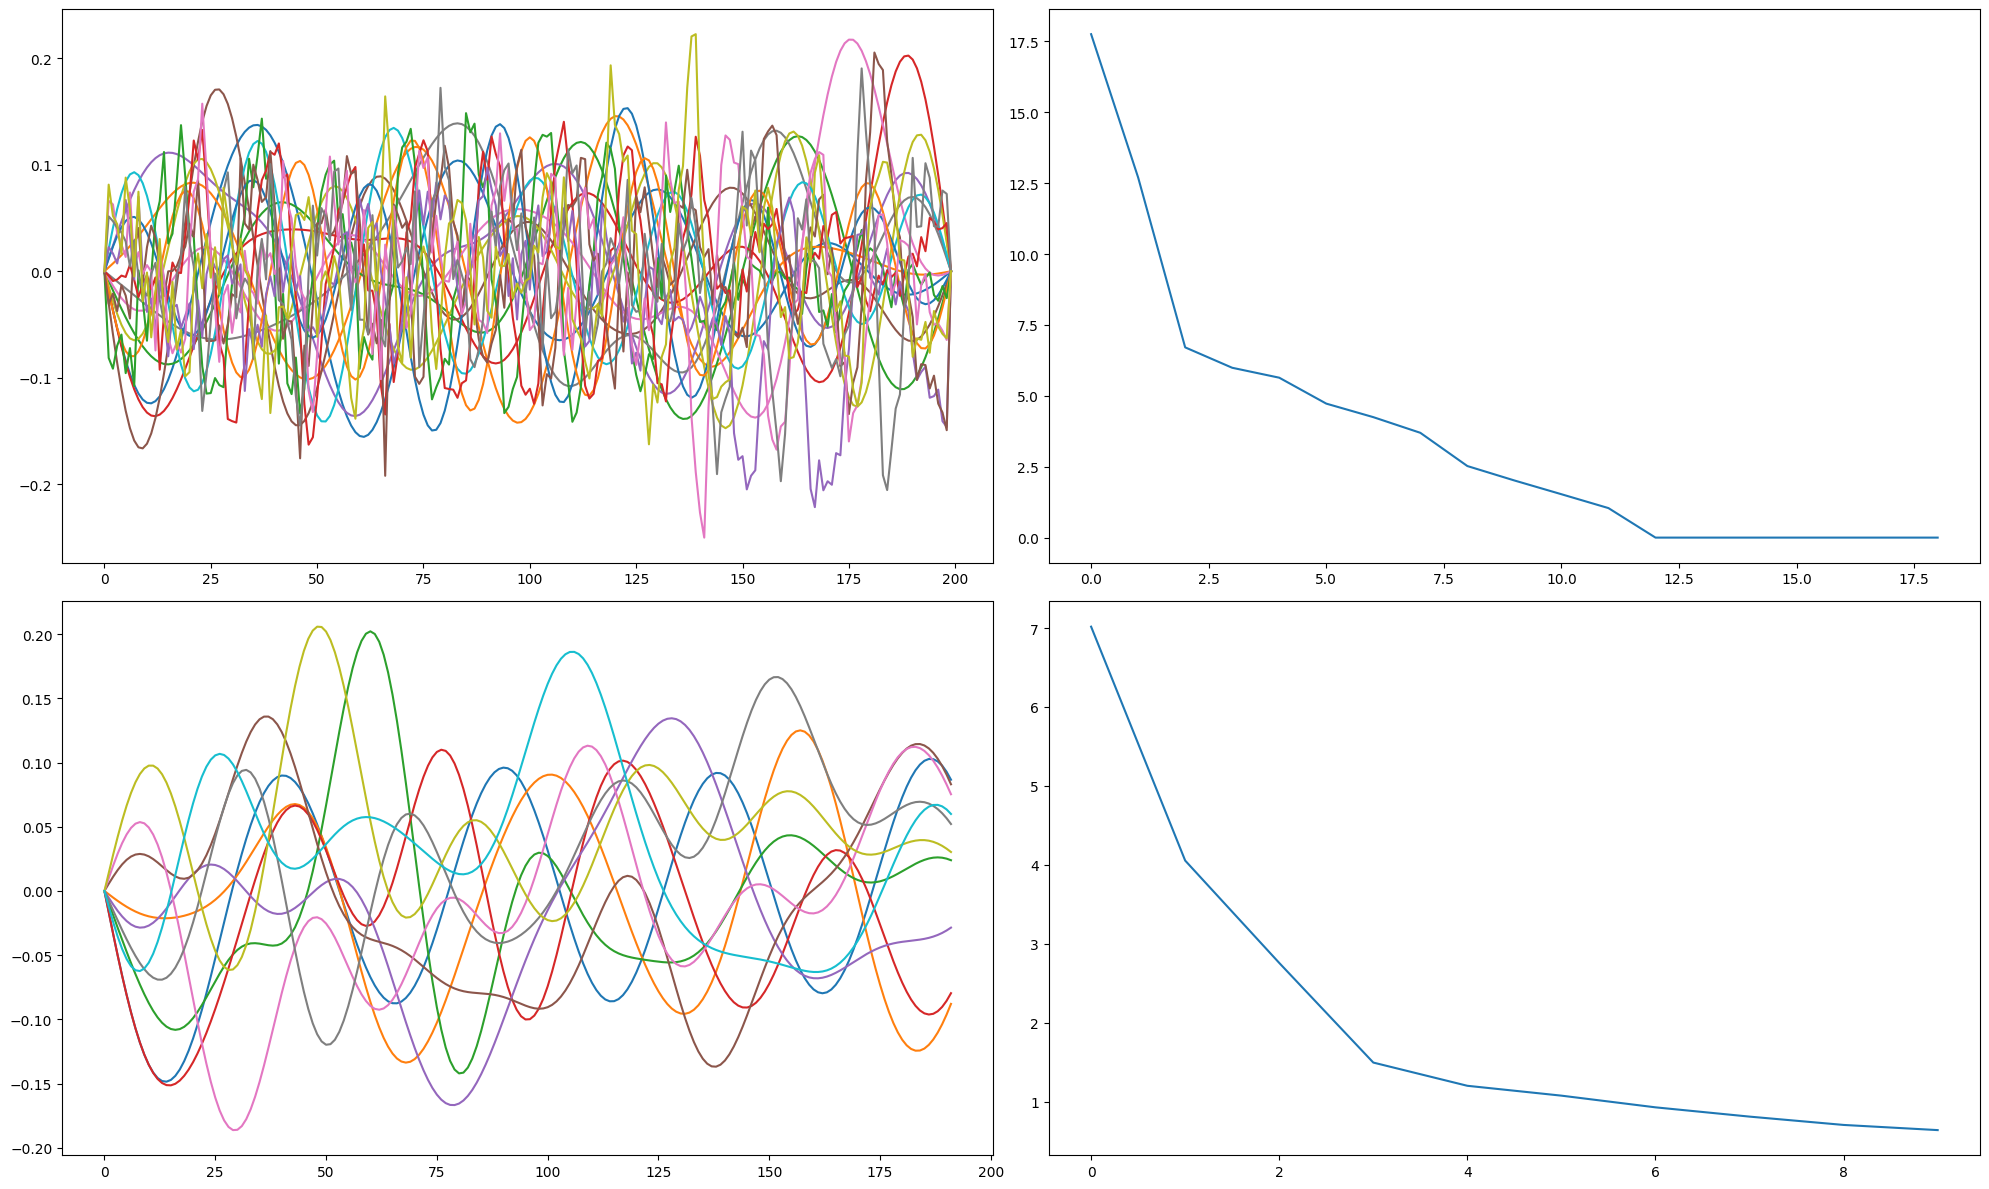

In [ ]:
from sklearn.utils.extmath import randomized_svd
import jax.numpy as jnp

def mse(datapred, datatrue):
    return jnp.mean(jnp.sum((datapred - datatrue)**2, axis = -1))
def rmsre(datapred, datatrue):
    return jnp.mean(jnp.sqrt(jnp.sum((datapred - datatrue)**2, axis = -1))/jnp.sqrt(jnp.sum((datatrue)**2, axis = -1)))

def mae(datapred, datatrue):
    return jnp.mean(jnp.sum(jnp.abs(datapred - datatrue), axis = -1))

def mre(datapred, datatrue):
    return jnp.mean(jnp.abs(datapred - datatrue)) / jnp.mean(jnp.abs(datatrue))


##TODO add mae and MRE to compare metrics 

_df_cf.shape, _df_il.shape
# df = np.stack([_df_cf, _df_il], axis = -1)

nx, nt= df.shape

modes_il = 15
U_il, S_full_il, Vt_il = randomized_svd(_df_il, n_components=modes_il, random_state=42)

modes_cf = 10
U_cf, S_full_cf, Vt_cf = randomized_svd(_df_cf, n_components=modes_cf, random_state=42)
fig, axes = plt.subplots(2, 2, figsize = (20,12))

print(f'Reconstruction of inline: {rmsre(_df_il, np.dot(_df_il, Vt_il.T) @ Vt_il) * 100}')
print(f'Reconstuction of cross flow: {rmsre(_df_cf, np.dot(_df_cf, Vt_cf.T) @ Vt_cf) * 100}')

axes[0,0].plot(Vt_il.T)
axes[0,1].plot(S_full_il)
axes[1,0].plot(Vt_cf.T)
axes[1,1].plot(S_full_cf)
plt.tight_layout()


nsensors=3, sensors=[48, 96, 144, -1], nt=24946, nx=192


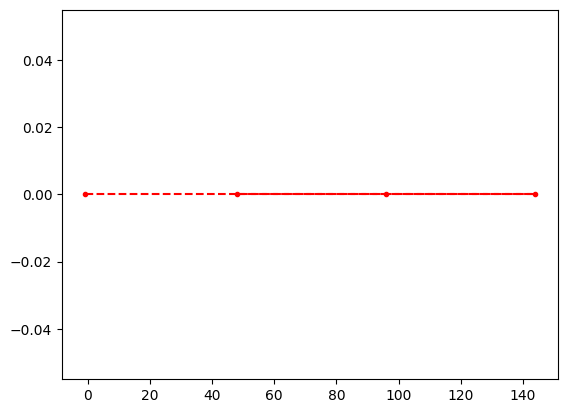

In [ ]:
from utils.models_diffrax import *
from sklearn.utils.extmath import randomized_svd
from sklearn.preprocessing import MinMaxScaler


nt, nx = _df_cf.shape
nsensors = 5


# Select random sensor locations
sensor_location = [int((i+1)/(nsensors+1) *Nx ) for i in range(nsensors)]
sensor_location.append(-1)
print(f"nsensors={nsensors}, sensors={sensor_location}, nt={nt}, nx={nx}")


plt.plot(sensor_location, np.zeros_like(sensor_location), 'r.--')

CF: X=(24927, 20, 4), Y=(24927, 192)
IL: X=(24927, 20, 4), Y=(24927, 200)


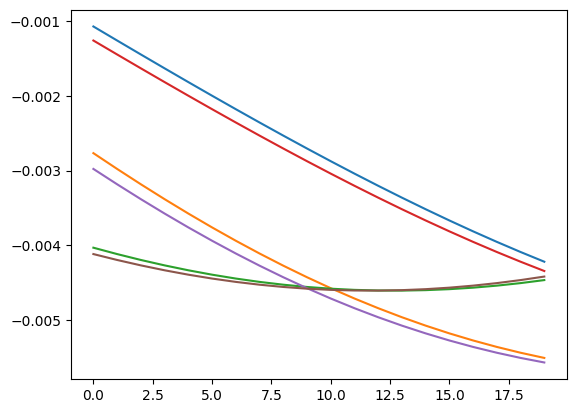

In [15]:
# Create lag-windowed sequences with time coordinate
def create_sequences(data, lag_size, stride=1):
    """Create lagged sequences from spatial-temporal data with optional striding.
    
    Args:
        data: Input data array of shape (n_timesteps, n_features)
        lag_size: Number of timesteps in each sequence
        stride: Spacing between timesteps within each sequence (default: 1).
                stride > 1 creates longer temporal windows with fewer samples.
                Each sequence spans lag_size * stride timesteps.
    """
    data_with_time = np.hstack([data, np.linspace(0, 1, data.shape[0])[:, None]])
    # Each sequence spans lag_size * stride timesteps
    max_start_idx = data_with_time.shape[0] - lag_size * stride
    sequences = np.stack([data_with_time[i:i+lag_size*stride:stride] for i in range(max_start_idx + 1)])
    return sequences

stride = 1
lag = 20

seq_cf = create_sequences(_df_cf, lag, stride = stride)
seq_il = create_sequences(_df_il, lag, stride = stride)

X_cf = seq_cf[:, :, sensor_location]
Y_cf = seq_cf[:, -1, :-1]

X_il = seq_il[:, :, sensor_location]
Y_il = seq_il[:, -1, :-1]

print(f"CF: X={X_cf.shape}, Y={Y_cf.shape}")
print(f"IL: X={X_il.shape}, Y={Y_il.shape}")
idx = np.random.choice(X_cf.shape[0], 1)[0]
plt.plot(X_cf[idx,:,:-1])
plt.plot(X_cf[idx+1,:,:-1])

In [16]:
from utils.models_diffrax import *
from sklearn.utils.extmath import randomized_svd
from sklearn.preprocessing import MinMaxScaler

np.random.seed(42)
split = 0.8
n_total = X_cf.shape[0]
n_train = int(split * n_total)
n_valid = int((1 - split) / 2 * n_total)
n_test  = n_total - n_train - n_valid

all_indices   = np.arange(n_total)
train_indices = all_indices[:n_train]
valid_indices = all_indices[n_train:n_train + n_valid]
test_indices  = all_indices[n_train + n_valid:]

print(f"Total: {n_total} | Train: {n_train} | Valid: {n_valid} | Test: {n_test}")

# Split CF and IL data
def split_data(X, Y, indices_dict):
    return {k: (X[idx], Y[idx]) for k, idx in indices_dict.items()}

cf_splits = split_data(X_cf, Y_cf, {'train': train_indices, 'valid': valid_indices, 'test': test_indices})
il_splits = split_data(X_il, Y_il, {'train': train_indices, 'valid': valid_indices, 'test': test_indices})

X_cf_train, Y_cf_train = cf_splits['train']
X_cf_valid, Y_cf_valid = cf_splits['valid']
X_cf_test,  Y_cf_test  = cf_splits['test']

X_il_train, Y_il_train = il_splits['train']
X_il_valid, Y_il_valid = il_splits['valid']
X_il_test,  Y_il_test  = il_splits['test']

# POD bases
def compute_pod_basis(Y_train, n_modes):
    _, S, Vt = randomized_svd(Y_train, n_components=n_modes, random_state=42)
    return Vt[:n_modes, :], S[:n_modes]

V_cf, S_cf = compute_pod_basis(Y_cf_train, modes_cf)
V_il, S_il = compute_pod_basis(Y_il_train, modes_il)

# Project to POD space
snapshots_train_cf_pod = Y_cf_train @ V_cf.T
snapshots_valid_cf_pod = Y_cf_valid @ V_cf.T
snapshots_test_cf_pod  = Y_cf_test  @ V_cf.T

snapshots_train_il_pod = Y_il_train @ V_il.T
snapshots_valid_il_pod = Y_il_valid @ V_il.T
snapshots_test_il_pod  = Y_il_test  @ V_il.T

# Combine CF + IL sensors and POD coefficients
X_train = np.concatenate([X_cf_train[:, :, :-1], X_il_train], axis=-1)
X_valid = np.concatenate([X_cf_valid[:, :, :-1], X_il_valid], axis=-1)
X_test  = np.concatenate([X_cf_test[:,  :, :-1], X_il_test],  axis=-1)

pod_train = np.concatenate([snapshots_train_cf_pod, snapshots_train_il_pod], axis=-1)
pod_valid = np.concatenate([snapshots_valid_cf_pod, snapshots_valid_il_pod], axis=-1)
pod_test  = np.concatenate([snapshots_test_cf_pod,  snapshots_test_il_pod],  axis=-1)

# Scale POD coefficients to [0, 1]
scalerU     = MinMaxScaler().fit(pod_train)
U_train_pod = scalerU.transform(pod_train)
U_valid_pod = scalerU.transform(pod_valid)
U_test_pod  = scalerU.transform(pod_test)

# CDE data dicts
train_data_cde, data_size = prepare_data_CDE(X_train, U_train_pod)
valid_data_cde, _         = prepare_data_CDE(X_valid, U_valid_pod)
test_data_cde,  _         = prepare_data_CDE(X_test,  U_test_pod)

# POD reconstruction errors (sanity check)
def recon_error(pod, V, Y_true, label):
    err = rmsre(pod @ V, Y_true)
    print(f"{label} POD reconstruction error: {err*100:.2f}%")

recon_error(snapshots_train_cf_pod, V_cf, Y_cf_train, "Train CF")
recon_error(snapshots_valid_cf_pod, V_cf, Y_cf_valid, "Valid CF")
recon_error(snapshots_test_cf_pod,  V_cf, Y_cf_test,  "Test  CF")
recon_error(snapshots_train_il_pod, V_il, Y_il_train, "Train IL")
recon_error(snapshots_valid_il_pod, V_il, Y_il_valid, "Valid IL")
recon_error(snapshots_test_il_pod,  V_il, Y_il_test,  "Test  IL")


Total: 24927 | Train: 19941 | Valid: 2492 | Test: 2494
Train CF POD reconstruction error: 12.00%
Valid CF POD reconstruction error: 7.66%
Test  CF POD reconstruction error: 8.14%
Train IL POD reconstruction error: 0.00%
Valid IL POD reconstruction error: 0.00%
Test  IL POD reconstruction error: 0.00%


In [17]:
# Compute mode importance weights from singular values
# Strategy (Option B): equal total weight per direction (50% CF, 50% IL),
# with energy-ranked weights within each direction.
# This prevents CF and IL from dominating each other due to magnitude differences.

# Within each direction: normalize so modes sum to 0.5 (each direction gets 50% total weight)
S_cf_normalized = (S_cf / np.sum(S_cf)) * 0.5   # CF modes: total weight = 0.5
S_il_normalized = (S_il / np.sum(S_il)) * 0.5   # IL modes: total weight = 0.5

# Convert to percentages for readability (relative within direction)
S_cf_percent = (S_cf / np.sum(S_cf)) * 100
S_il_percent = (S_il / np.sum(S_il)) * 100

# Combine weights (CF modes first, then IL modes) — sum = 1.0 by construction
mode_weights = np.concatenate([S_cf_normalized, S_il_normalized])

print(f"\n{'='*70}")
print(f"POD Mode Importance Weighting  [Option B: 50% CF / 50% IL]")
print(f"{'='*70}")
print(f"\nCross-Flow (CF) Modes  (total weight = {np.sum(S_cf_normalized):.2f})")
for i, (w, pct) in enumerate(zip(S_cf_normalized, S_cf_percent)):
    print(f"  Mode {i+1:2d}: {pct:6.2f}% within CF  (weight: {w:.4f})")

print(f"\nInline (IL) Modes  (total weight = {np.sum(S_il_normalized):.2f})")
for i, (w, pct) in enumerate(zip(S_il_normalized, S_il_percent)):
    print(f"  Mode {i+1:2d}: {pct:6.2f}% within IL  (weight: {w:.4f})")

print(f"\nCombined:")
print(f"  CF total: {np.sum(S_cf_normalized):.4f}  |  IL total: {np.sum(S_il_normalized):.4f}")
print(f"  Sum:      {np.sum(mode_weights):.4f}  (should be 1.0)")
print(f"  Min:      {np.min(mode_weights):.4f}")
print(f"  Max:      {np.max(mode_weights):.4f}")
print(f"{'='*70}\n")

# Convert to JAX array for use in loss functions
mode_weights_jax = jnp.array(mode_weights)



POD Mode Importance Weighting  [Option B: 50% CF / 50% IL]

Cross-Flow (CF) Modes  (total weight = 0.50)
  Mode  1:  33.03% within CF  (weight: 0.1651)
  Mode  2:  19.07% within CF  (weight: 0.0954)
  Mode  3:  13.01% within CF  (weight: 0.0651)
  Mode  4:   7.78% within CF  (weight: 0.0389)
  Mode  5:   6.14% within CF  (weight: 0.0307)
  Mode  6:   5.29% within CF  (weight: 0.0265)
  Mode  7:   4.60% within CF  (weight: 0.0230)
  Mode  8:   4.20% within CF  (weight: 0.0210)
  Mode  9:   3.60% within CF  (weight: 0.0180)
  Mode 10:   3.26% within CF  (weight: 0.0163)

Inline (IL) Modes  (total weight = 0.50)
  Mode  1:  27.10% within IL  (weight: 0.1355)
  Mode  2:  18.53% within IL  (weight: 0.0926)
  Mode  3:   9.91% within IL  (weight: 0.0495)
  Mode  4:   8.60% within IL  (weight: 0.0430)
  Mode  5:   7.59% within IL  (weight: 0.0380)
  Mode  6:   6.61% within IL  (weight: 0.0331)
  Mode  7:   6.21% within IL  (weight: 0.0310)
  Mode  8:   5.59% within IL  (weight: 0.0279)
  Mode

In [18]:
key = jr.PRNGKey(42)
model_key_1, model_key_2, loader_key = jr.split(key, 3)
hidden_size  = 16
width_size   = 64
depth        = 4
output_size  = train_data_cde['Y'].shape[-1]
print(f"data_size={2*nsensors}, output_size={output_size}")

model_cde = NeuralCDE(
    2 * nsensors,
    hidden_size,
    width_size,
    depth,
    activation_cde     = jnn.tanh,
    activation_decoder = jnn.gelu,
    output_size        = output_size,
    decoder_sizes      = [128, 256],
    use_layer_norm     = False,
    key                = model_key_1,
)
print(f"coeffs shape: {train_data_cde['coeffs'][0].shape}, Y shape: {train_data_cde['Y'].shape}")


data_size=6, output_size=29
coeffs shape: (19941, 19, 6), Y shape: (19941, 29)


In [19]:
import jax
import jax.tree_util as jtu

# Count parameters in Neural CDE model
def count_parameters(model):
    """Count total number of parameters in a JAX/Equinox model"""
    leaves = jtu.tree_leaves(model)
    total_params = sum(x.size for x in leaves if hasattr(x, 'size'))
    return total_params

cde_params = count_parameters(model_cde)
print(f"\n{'='*60}")
print(f"Neural CDE Model Parameters: {cde_params:,}")
print(f"{'='*60}\n")


Neural CDE Model Parameters: 76,922



In [20]:
lr = 1e-2
epochs = 200
batch_size = 64
model_cde, train_losses_cde, valid_losses_cde = fit_CDE_weighted(model_cde, train_data_cde, valid_data_cde, mode_weights_jax, epochs=epochs, batch_size=batch_size, lr=1e-2, early_stopping=10)

Epoch  11/200 | Train 3.6309e-03 | Valid 1.6222e-02 | Time 19.53s | Patience 9/10
Early stopping at epoch 11 (best valid 9.9986e-03)


Text(0.5, 1.0, 'Train and validation Loss over Steps')

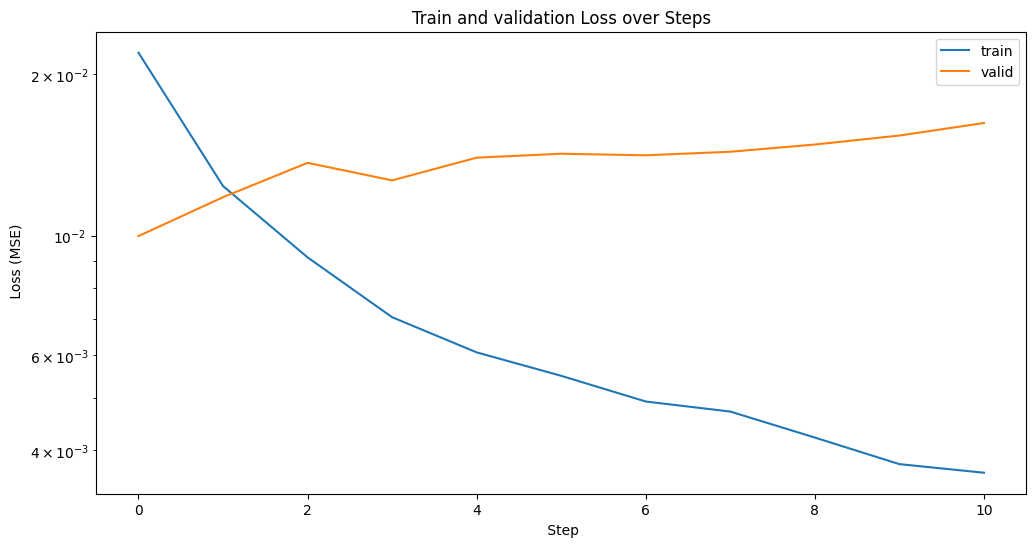

In [21]:
fig, axes = plt.subplots(1, 1, figsize = (12,6))

axes.plot(train_losses_cde  , label = 'train')
axes.plot(valid_losses_cde , label = 'valid')
axes.legend()
axes.set_yscale('log')
axes.set_xlabel(' Step') 
axes.set_ylabel(' Loss (MSE)')
axes.set_title('Train and validation Loss over Steps')


## Neural CDE — Evaluation

In [22]:
preds_cde_train = jax.vmap(model_cde)(train_data_cde['ts'], train_data_cde['coeffs'])
print(preds_cde_train[:, :modes_cf].shape, V_cf.shape)
preds_cde_cf_train = scalerU.inverse_transform(preds_cde_train)[:, :modes_cf] @ V_cf
preds_cde_il_train = scalerU.inverse_transform(preds_cde_train)[:, modes_cf:] @ V_il
print(f'Reconstruction error on train CF: {rmsre(preds_cde_cf_train, Y_cf_train) * 100:.2f}%')
print(f'Reconstruction error on train IL: {rmsre(preds_cde_il_train, Y_il_train) * 100:.2f}%')

preds_cde_valid = jax.vmap(model_cde)(valid_data_cde['ts'], valid_data_cde['coeffs'])
preds_cde_cf_valid = scalerU.inverse_transform(preds_cde_valid)[:, :modes_cf] @ V_cf
preds_cde_il_valid = scalerU.inverse_transform(preds_cde_valid)[:, modes_cf:] @ V_il
print(f'Reconstruction error on valid CF: {rmsre(preds_cde_cf_valid, Y_cf_valid) * 100:.2f}%')
print(f'Reconstruction error on valid IL: {rmsre(preds_cde_il_valid, Y_il_valid) * 100:.2f}%')

preds_cde_test = jax.vmap(model_cde)(test_data_cde['ts'], test_data_cde['coeffs'])
preds_cde_cf_test = scalerU.inverse_transform(preds_cde_test)[:, :modes_cf] @ V_cf
preds_cde_il_test = scalerU.inverse_transform(preds_cde_test)[:, modes_cf:] @ V_il
print(f'Reconstruction error on test CF: {rmsre(preds_cde_cf_test, Y_cf_test) * 100:.2f}%')
print(f'Reconstruction error on test IL: {rmsre(preds_cde_il_test, Y_il_test) * 100:.2f}%')



(19941, 10) (10, 192)
Reconstruction error on train CF: 53.12%
Reconstruction error on train IL: 102.24%
Reconstruction error on valid CF: 37.77%
Reconstruction error on valid IL: 121.09%
Reconstruction error on test CF: 37.79%
Reconstruction error on test IL: 150.33%


In [23]:
print(f'RMSE train: {rmsre(jax.vmap(model_cde)(train_data_cde['ts'], train_data_cde['coeffs']), train_data_cde['Y']) *100} %')
print(f'RMSE valid: {rmsre(jax.vmap(model_cde)(valid_data_cde['ts'], valid_data_cde['coeffs']), valid_data_cde['Y']) *100} %')
print(f'RMSE test: {rmsre(jax.vmap(model_cde)(test_data_cde['ts'], test_data_cde['coeffs']), test_data_cde['Y']) *100} %')

print(f'MSE train: {mse(jax.vmap(model_cde)(train_data_cde['ts'], train_data_cde['coeffs']), train_data_cde['Y'])}')
print(f'MSE valid: {mse(jax.vmap(model_cde)(valid_data_cde['ts'], valid_data_cde['coeffs']), valid_data_cde['Y'])}')
print(f'MSE test: {mse(jax.vmap(model_cde)(test_data_cde['ts'], test_data_cde['coeffs']), test_data_cde['Y'])}')

RMSE train: 24.56584930419922 %
RMSE valid: 23.150177001953125 %
RMSE test: 32.4199333190918 %
MSE train: 0.34405526518821716
MSE valid: 0.2988562285900116
MSE test: 0.6321219205856323


In [24]:
from utils.plotting import * 
import os

interp_train = jax.vmap(
    lambda ts, coeffs: diffrax.CubicInterpolation(ts, coeffs),
    in_axes=(0, 0)
)(train_data_cde["ts"],  tuple(train_data_cde["coeffs"]))

sensors_train = jax.vmap(
    lambda interp, ts: jax.vmap(interp.evaluate)(ts),
    in_axes=(0, 0)
)(interp_train, train_data_cde["ts"])


interp_valid = jax.vmap(
    lambda ts, coeffs: diffrax.CubicInterpolation(ts, coeffs),
    in_axes=(0, 0)
)(valid_data_cde["ts"],  tuple(valid_data_cde["coeffs"]))

sensors_valid = jax.vmap(
    lambda interp, ts: jax.vmap(interp.evaluate)(ts),
    in_axes=(0, 0)
)(interp_valid, valid_data_cde["ts"])

interp_test = jax.vmap(
    lambda ts, coeffs: diffrax.CubicInterpolation(ts, coeffs),
    in_axes=(0, 0)
)(test_data_cde["ts"],  tuple(test_data_cde["coeffs"]))

sensors_test = jax.vmap(
    lambda interp, ts: jax.vmap(interp.evaluate)(ts),
    in_axes=(0, 0)
)(interp_test, test_data_cde["ts"])


plot_steps = 200
x = jnp.linspace(0,1,nx)

In [25]:
# Use normalized sensor input data for SHRED
train_data_shred = {'S_i':X_train[:,:,:-1], 'Y': U_train_pod}
valid_data_shred = {'S_i':X_valid[:,:,:-1], 'Y': U_valid_pod}
test_data_shred = {'S_i':X_test[:,:,:-1], 'Y': U_test_pod}


In [ ]:
model_key_shred, = jr.split(jr.PRNGKey(0), 1)
output_size_shred = train_data_shred['Y'].shape[-1]
print(f"SHRED: input_size={2*nsensors}, output_size={output_size_shred}")

model_shred = SHRED(
    2 * nsensors, output_size_shred,
    hidden_size=64, hidden_layers=4,
    decoder_sizes=[128, 256],
    activation=jax.nn.tanh,
    key=model_key_shred,
)
shred_params = count_parameters(model_shred)
print(f"SHRED parameters: {shred_params:,}")

# Multi-stage lr decay
model_shred, tl1, vl1 = fit_SHRED_weighted(
    model_shred, train_data_shred, valid_data_shred, mode_weights_jax,
    epochs=200, batch_size=64, lr=1e-2, early_stopping=10,
)
model_shred, tl2, vl2 = fit_SHRED_weighted(
    model_shred, train_data_shred, valid_data_shred, mode_weights_jax,
    epochs=200, batch_size=64, lr=1e-3, early_stopping=10,
)
model_shred, tl3, vl3 = fit_SHRED_weighted(
    model_shred, train_data_shred, valid_data_shred, mode_weights_jax,
    epochs=200, batch_size=64, lr=1e-4, early_stopping=10,
)
train_losses_shred = tl1 + tl2 + tl3
valid_losses_shred = vl1 + vl2 + vl3
print(f"Total SHRED epochs: {len(train_losses_shred)}")


SHRED: input_size=6, output_size=29
SHRED parameters: 166,813
Epoch  14/200 | Train 2.6926e-03 | Valid 1.5973e-02 | Time 4.67s | Patience 9/10
Early stopping at epoch 14 (best valid 1.1862e-02)
Epoch  12/200 | Train 2.8318e-03 | Valid 1.6956e-02 | Time 4.41s | Patience 9/10
Early stopping at epoch 12 (best valid 1.2595e-02)


Text(0.5, 1.0, 'Train and validation Loss over Steps')

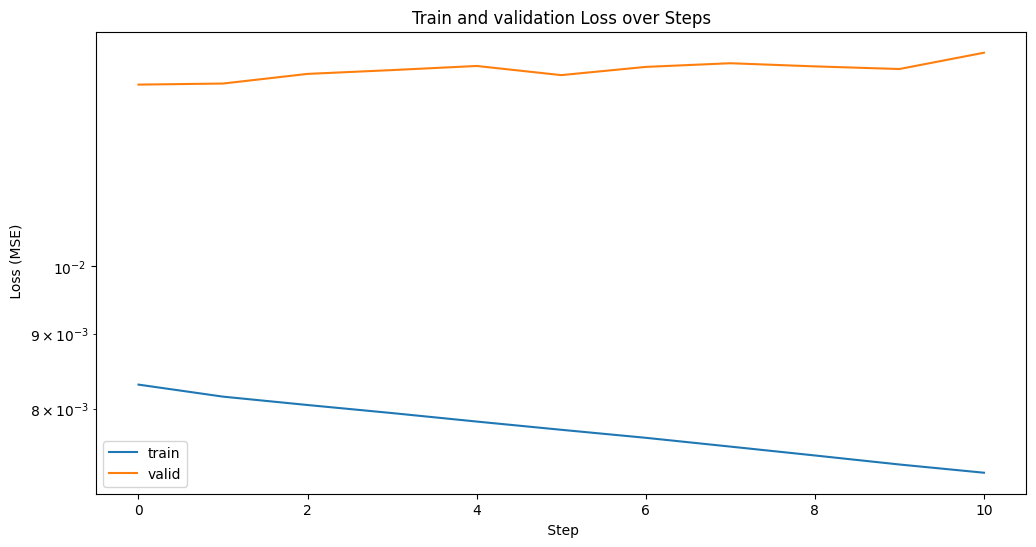

In [ ]:
fig, axes = plt.subplots(1, 1, figsize = (12,6))

axes.plot(train_losses_shred, label = 'train')
axes.plot(valid_losses_shred, label = 'valid')
axes.legend()
axes.set_yscale('log')
axes.set_xlabel(' Step') 
axes.set_ylabel(' Loss (MSE)')
axes.set_title('Train and validation Loss over Steps')


Text(0.5, 1.0, 'Train and validation Loss over Steps')

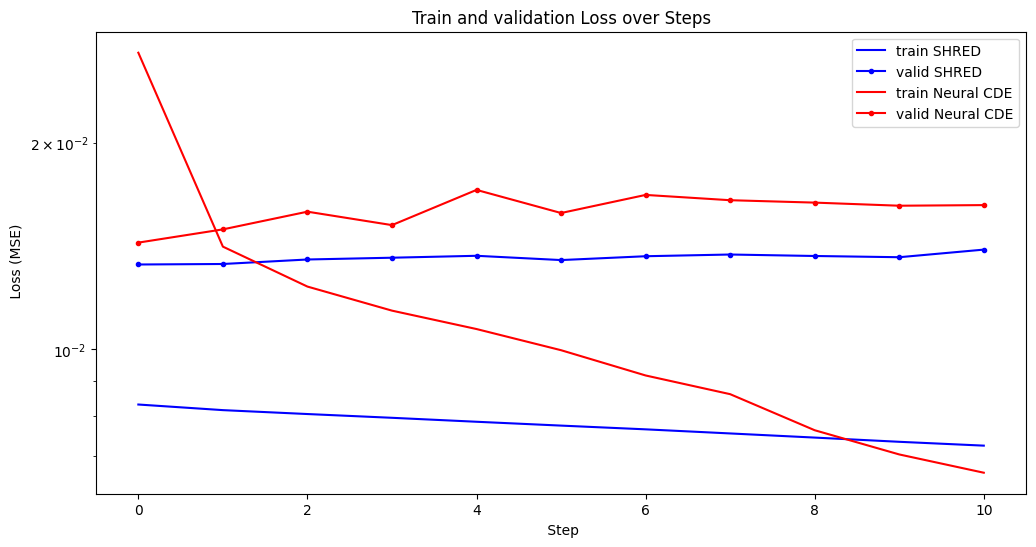

In [ ]:
fig, axes = plt.subplots(1, 1, figsize = (12,6))

axes.plot(train_losses_shred, 'b-', label = 'train SHRED')
axes.plot(valid_losses_shred, 'b.-', label = 'valid SHRED')
axes.plot(train_losses_cde, 'r-', label = 'train Neural CDE')
axes.plot(valid_losses_cde, 'r.-', label = 'valid Neural CDE')
axes.legend()
axes.set_yscale('log')
axes.set_xlabel(' Step') 
axes.set_ylabel(' Loss (MSE)')
axes.set_title('Train and validation Loss over Steps')


In [ ]:
preds_shred_train = jax.vmap(model_shred)(train_data_shred['S_i'])
preds_shred_valid = jax.vmap(model_shred)(valid_data_shred['S_i'])
preds_shred_test  = jax.vmap(model_shred)(test_data_shred['S_i'])

preds_shred_cf_train = scalerU.inverse_transform(preds_shred_train)[:, :modes_cf] @ V_cf
preds_shred_il_train = scalerU.inverse_transform(preds_shred_train)[:, modes_cf:] @ V_il
preds_shred_cf_valid = scalerU.inverse_transform(preds_shred_valid)[:, :modes_cf] @ V_cf
preds_shred_il_valid = scalerU.inverse_transform(preds_shred_valid)[:, modes_cf:] @ V_il
preds_shred_cf_test  = scalerU.inverse_transform(preds_shred_test)[:, :modes_cf] @ V_cf
preds_shred_il_test  = scalerU.inverse_transform(preds_shred_test)[:, modes_cf:] @ V_il

print(f"{'='*60}")
print(f"SHRED Reconstruction Errors")
print(f"{'='*60}")
print(f"Train  CF: {rmsre(preds_shred_cf_train, Y_cf_train)*100:.2f}%  |  IL: {rmsre(preds_shred_il_train, Y_il_train)*100:.2f}%")
print(f"Valid  CF: {rmsre(preds_shred_cf_valid, Y_cf_valid)*100:.2f}%  |  IL: {rmsre(preds_shred_il_valid, Y_il_valid)*100:.2f}%")
print(f"Test   CF: {rmsre(preds_shred_cf_test,  Y_cf_test )*100:.2f}%  |  IL: {rmsre(preds_shred_il_test,  Y_il_test )*100:.2f}%")


SHRED CF train: (7213, 200), IL train: (7213, 200)
Train CF shaped: (7213, 200), Train IL shaped: (7213, 200)
SHRED train reconstruction il error RMSE: 55.46%
SHRED train reconstruction cf error RMSE: 30.14%
SHRED CF valid: (901, 200), IL valid: (901, 200)
SHRED valid reconstruction il error RMSE: 62.90%
SHRED valid reconstruction cf error RMSE: 52.93%
SHRED CF test: (903, 200), IL test: (903, 200)
SHRED test reconstruction il error RMSE: 74.16%
SHRED test reconstruction cf error RMSE: 58.62%


In [ ]:
fps  = 20

(7213, 20, 4) (7213, 200) (7213, 200) (7213, 200)


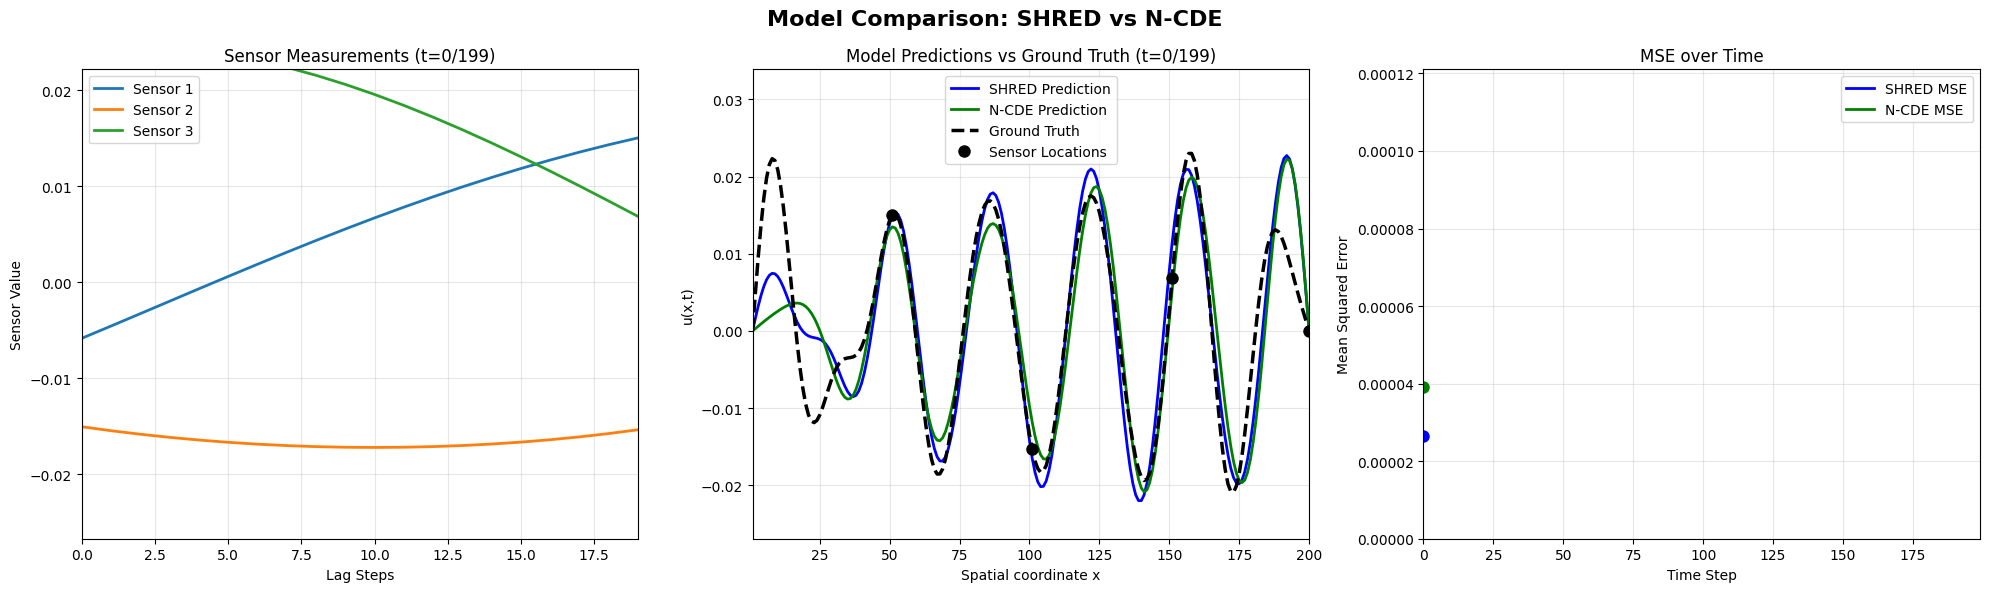

SHRED cf RMSE: 37.650394439697266
NCDE cf RMSE: 57.95510482788086
N-CDE animation saved to animations/comparison_shred_cde_cf.gif


In [ ]:
plot_steps = 200
idx = np.random.randint(0, X_cf_train.shape[0]-plot_steps)
Nt_cf, Nx_cf = Y_cf_train.shape

x = np.linspace(1, Nx_cf, Nx_cf)
from utils.plotting import create_comparison_animation
print(X_cf_train.shape, preds_cde_cf_train.shape, preds_shred_cf_train.shape, Y_cf_train.shape)
anim_comparison = create_comparison_animation(x, X_cf_train[idx:(idx+plot_steps),:,:-1], preds_shred_cf_train[idx:(idx+plot_steps)], preds_cde_cf_train[idx:(idx+plot_steps)], Y_cf_train[idx:(idx+plot_steps)] ,np.array(sensor_location), nsensors=nsensors)
animations_dir = 'animations'
print(f'SHRED cf RMSE: {rmsre(preds_shred_cf_train[idx:(idx+plot_steps)], Y_cf_train[idx:(idx+plot_steps)])*100}')
print(f'NCDE cf RMSE: {rmsre(preds_cde_cf_train[idx:(idx+plot_steps)], Y_cf_train[idx:(idx+plot_steps)])*100}')

# Save the animation to animations directory
filename = 'comparison_shred_cde_cf.gif'
anim_comparison.save(os.path.join(animations_dir, filename), writer='pillow', fps=fps)
print(f"N-CDE animation saved to {os.path.join(animations_dir, filename)}")

(7213, 20, 4) (7213, 200) (7213, 200) (7213, 200)


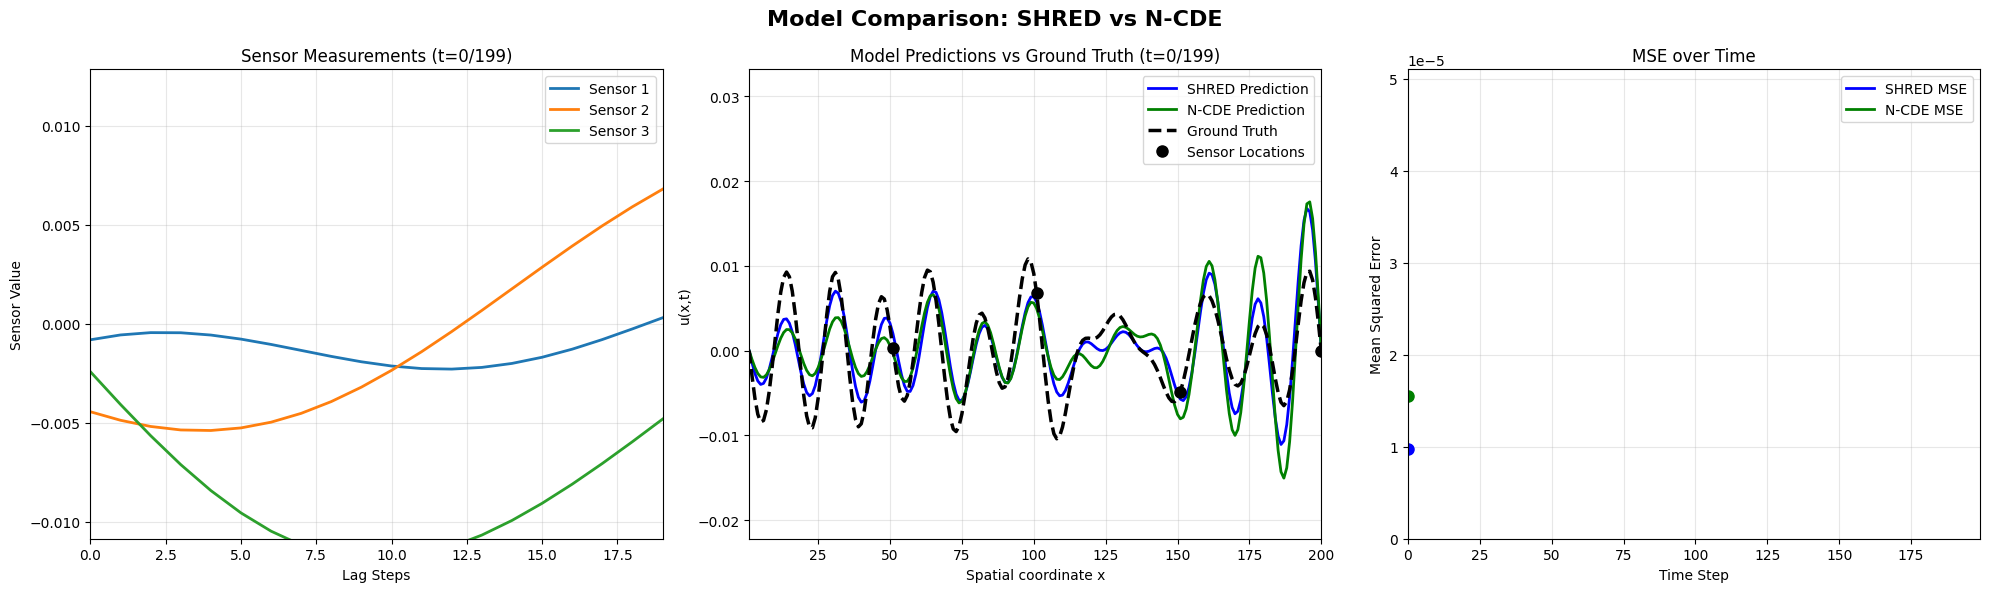

SHRED il RMSE: 45.04945373535156
NCDE il RMSE: 61.0124397277832
N-CDE animation saved to animations/comparison_shred_cde_il.gif


In [ ]:
plot_steps = 200
idx = np.random.randint(0, X_il_train.shape[0]-plot_steps)
from utils.plotting import create_comparison_animation

print(X_il_train.shape, preds_cde_il_train.shape, preds_shred_il_train.shape, Y_il_train.shape)
Nt_il, Nx_il = Y_il_train.shape

x = np.linspace(1, Nx_il, Nx_il)
anim_comparison = create_comparison_animation(x, X_il_train[idx:(idx+plot_steps),:,:-1], preds_shred_il_train[idx:(idx+plot_steps)], preds_cde_il_train[idx:(idx+plot_steps)], Y_il_train[idx:(idx+plot_steps)] ,np.array(sensor_location), nsensors=nsensors)
animations_dir = 'animations'
print(f'SHRED il RMSE: {rmsre(preds_shred_il_train[idx:(idx+plot_steps)], Y_il_train[idx:(idx+plot_steps)])*100}')
print(f'NCDE il RMSE: {rmsre(preds_cde_il_train[idx:(idx+plot_steps)], Y_il_train[idx:(idx+plot_steps)])*100}')
# Save the animation to animations directory
filename = 'comparison_shred_cde_il.gif'
anim_comparison.save(os.path.join(animations_dir, filename), writer='pillow', fps=fps)
print(f"N-CDE animation saved to {os.path.join(animations_dir, filename)}")

POD MSE with predictions animation saved to animations/pod_mse_predictions.gif

MSE Summary Statistics (200 frames)
SHRED Mean MSE:       0.000391
SHRED Std MSE:        0.000109
SHRED Max MSE:        0.000627
SHRED Min MSE:        0.000234

Neural CDE Mean MSE:  0.000370
Neural CDE Std MSE:   0.000131
Neural CDE Max MSE:   0.000569
Neural CDE Min MSE:   0.000130

CDE Improvement:      5.50%



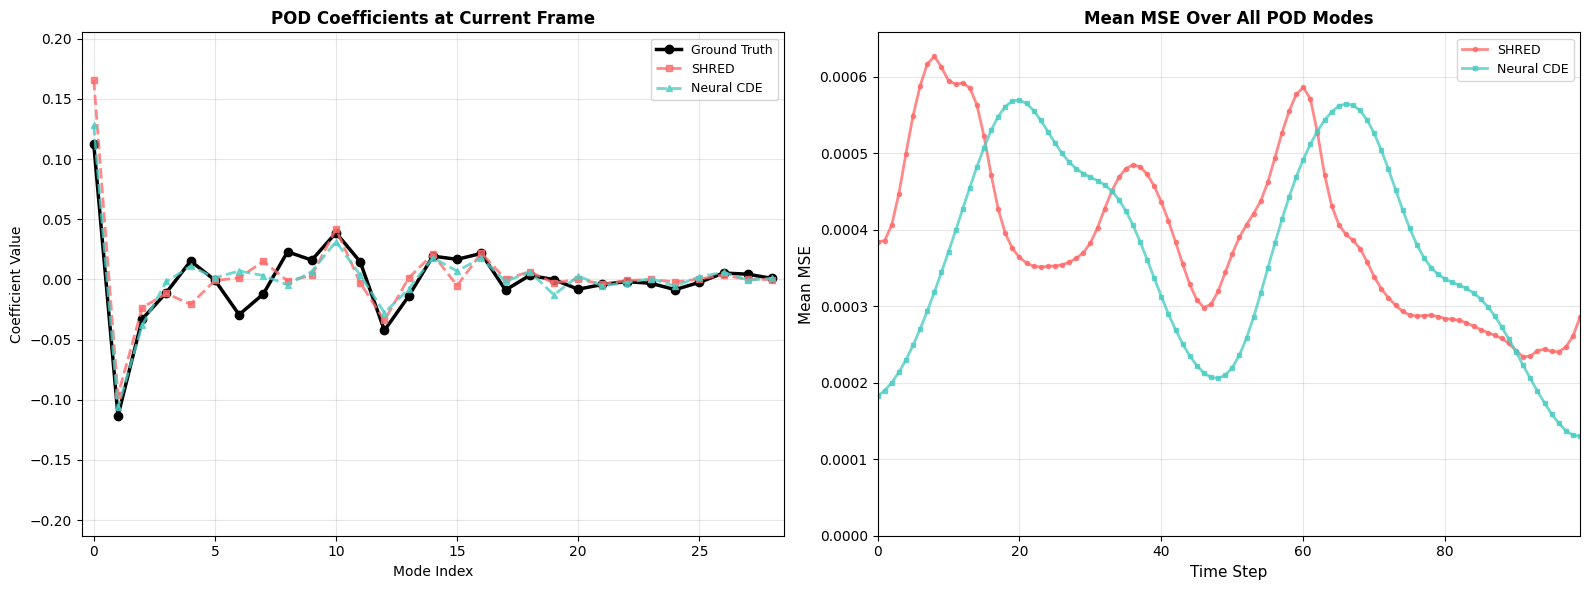

In [ ]:
# Compute MSE over all POD modes over time with predictions display
from matplotlib.animation import FuncAnimation

idx_start = np.random.randint(0, pod_test.shape[0] - 200)
plot_frames = 100

gt_modes =  scalerU.inverse_transform(U_test_pod[idx_start:idx_start+plot_frames])
shred_modes = scalerU.inverse_transform(preds_shred_test[idx_start:idx_start+plot_frames])
cde_modes = scalerU.inverse_transform(preds_cde_test[idx_start:idx_start+plot_frames])

# Compute MSE for each mode at each timestep
shred_mse_per_mode = (shred_modes - gt_modes)**2  # Shape: (200, 19)
cde_mse_per_mode = (cde_modes - gt_modes)**2      # Shape: (200, 19)

# Compute mean MSE across all modes for each timestep
shred_mean_mse = np.mean(shred_mse_per_mode, axis=1)  # Shape: (200,)
cde_mean_mse = np.mean(cde_mse_per_mode, axis=1)      # Shape: (200,)

# Create figure with 2 subplots
fig, (ax_pred, ax_mse_mean) = plt.subplots(1, 2, figsize=(16, 6))

# LEFT panel: POD Coefficients at Current Frame (Predictions)
ax_pred.set_title('POD Coefficients at Current Frame', fontsize=12, fontweight='bold')
ax_pred.set_xlabel('Mode Index')
ax_pred.set_ylabel('Coefficient Value')
modes_idx = np.arange(modes_cf + modes_il)
ax_pred.set_xlim(-0.5, modes_cf + modes_il - 0.5)
ax_pred.set_ylim(gt_modes.min() - 0.05, gt_modes.max() + 0.05)
ax_pred.grid(True, alpha=0.3)

line_gt, = ax_pred.plot([], [], 'o-', linewidth=2.5, markersize=6, label='Ground Truth', color='black')
line_shred, = ax_pred.plot([], [], 's--', linewidth=2, markersize=5, label='SHRED', color='#FF6B6B', alpha=0.8)
line_cde, = ax_pred.plot([], [], '^--', linewidth=2, markersize=5, label='Neural CDE', color='#4ECDC4', alpha=0.8)
ax_pred.legend(loc='upper right', fontsize=9)

# MIDDLE panel: Mean MSE over time
ax_mse_mean.set_xlabel('Time Step', fontsize=11)
ax_mse_mean.set_ylabel('Mean MSE', fontsize=11)
ax_mse_mean.set_title('Mean MSE Over All POD Modes', fontsize=12, fontweight='bold')
ax_mse_mean.set_xlim(0, plot_frames - 1)
ax_mse_mean.set_ylim(0, max(np.max(shred_mean_mse), np.max(cde_mean_mse)) * 1.05)
ax_mse_mean.grid(True, alpha=0.3)

# Initialize lines for MSE trajectories
line_mse_shred, = ax_mse_mean.plot([], [], 'o-', linewidth=2, markersize=3, label='SHRED', color='#FF6B6B', alpha=0.8)
line_mse_cde, = ax_mse_mean.plot([], [], 's-', linewidth=2, markersize=3, label='Neural CDE', color='#4ECDC4', alpha=0.8)
ax_mse_mean.legend(fontsize=9, loc='best')

time_steps = np.arange(plot_frames)

def animate(frame):
    # Update left panel with current frame values
    current_gt = gt_modes[frame]
    current_shred = shred_modes[frame]
    current_cde = cde_modes[frame]
    
    line_gt.set_data(modes_idx, current_gt)
    line_shred.set_data(modes_idx, current_shred)
    line_cde.set_data(modes_idx, current_cde)
    
    # Update middle panel with MSE trajectory up to current frame
    current_time = np.arange(frame + 1)
    line_mse_shred.set_data(current_time, shred_mean_mse[:frame + 1])
    line_mse_cde.set_data(current_time, cde_mean_mse[:frame + 1])
    
    return [line_gt, line_shred, line_cde, line_mse_shred, line_mse_cde]

anim = FuncAnimation(fig, animate, frames=plot_frames, interval=50, blit=True, repeat=True)
plt.tight_layout()

# Save animation
animations_dir = 'animations'
filename = 'pod_mse_predictions.gif'
anim.save(os.path.join(animations_dir, filename), writer='pillow', fps=20)
print(f"POD MSE with predictions animation saved to {os.path.join(animations_dir, filename)}")

# Print summary statistics
print(f"\n{'='*60}")
print(f"MSE Summary Statistics (200 frames)")
print(f"{'='*60}")
print(f"SHRED Mean MSE:       {np.mean(shred_mean_mse):.6f}")
print(f"SHRED Std MSE:        {np.std(shred_mean_mse):.6f}")
print(f"SHRED Max MSE:        {np.max(shred_mean_mse):.6f}")
print(f"SHRED Min MSE:        {np.min(shred_mean_mse):.6f}")
print()
print(f"Neural CDE Mean MSE:  {np.mean(cde_mean_mse):.6f}")
print(f"Neural CDE Std MSE:   {np.std(cde_mean_mse):.6f}")
print(f"Neural CDE Max MSE:   {np.max(cde_mean_mse):.6f}")
print(f"Neural CDE Min MSE:   {np.min(cde_mean_mse):.6f}")
print()
improvement = (1 - np.mean(cde_mean_mse) / np.mean(shred_mean_mse)) * 100
print(f"CDE Improvement:      {improvement:.2f}%")
print(f"{'='*60}\n")


## MLP Baseline

Simple MLP that flattens the sensor time-series window and maps directly to POD modes.

In [ ]:
train_data_mlp, mlp_input_size = prepare_data_SimpleMLP(X_train, U_train_pod, aggregation='flatten')
valid_data_mlp, _              = prepare_data_SimpleMLP(X_valid, U_valid_pod, aggregation='flatten')
test_data_mlp,  _              = prepare_data_SimpleMLP(X_test,  U_test_pod,  aggregation='flatten')

output_size_mlp = train_data_mlp['Y'].shape[-1]
print(f"MLP: input_size={mlp_input_size}, output_size={output_size_mlp}")

model_key_mlp = jr.PRNGKey(7)
model_mlp = SimpleMLPModel(
    input_size  = mlp_input_size,
    output_size = output_size_mlp,
    width_size  = 256,
    depth       = 4,
    activation  = jax.nn.tanh,
    key         = model_key_mlp,
)
mlp_params = count_parameters(model_mlp)
print(f"MLP parameters: {mlp_params:,}")


MLP: input_size=140, output_size=29
MLP parameters: 240,925


In [ ]:
# Train MLP (multi-stage lr decay, same schedule as SHRED)
model_mlp, train_losses_mlp, valid_losses_mlp = fit_SimpleMLPModel(
    model_mlp, train_data_mlp, valid_data_mlp,
    epochs=200, batch_size=64, lr=1e-2, early_stopping=10,
)
model_mlp, train_losses_mlp2, valid_losses_mlp2 = fit_SimpleMLPModel(
    model_mlp, train_data_mlp, valid_data_mlp,
    epochs=200, batch_size=64, lr=1e-3, early_stopping=10,
)
model_mlp, train_losses_mlp3, valid_losses_mlp3 = fit_SimpleMLPModel(
    model_mlp, train_data_mlp, valid_data_mlp,
    epochs=200, batch_size=64, lr=1e-4, early_stopping=10,
)

train_losses_mlp_all = train_losses_mlp + train_losses_mlp2 + train_losses_mlp3
valid_losses_mlp_all = valid_losses_mlp + valid_losses_mlp2 + valid_losses_mlp3
print(f"Total MLP epochs: {len(train_losses_mlp_all)}")


Epoch  19/200 | Train 1.3284e+00 | Valid 1.3873e+00 | Time 0.12s | Patience 9/10
Early stopping at epoch 19, best validation loss: 1.0159e+00
Epoch  28/200 | Train 3.1136e-01 | Valid 5.3721e-01 | Time 0.09s | Patience 9/10
Early stopping at epoch 28, best validation loss: 5.1347e-01
Epoch  11/200 | Train 3.2383e-01 | Valid 5.1691e-01 | Time 0.11s | Patience 9/10
Early stopping at epoch 11, best validation loss: 5.0218e-01
Total MLP epochs: 58


MLP Reconstruction Errors
Train  CF: 32.58%  |  IL: 57.77%
Valid  CF: 52.69%  |  IL: 74.22%
Test   CF: 55.90%  |  IL: 75.24%


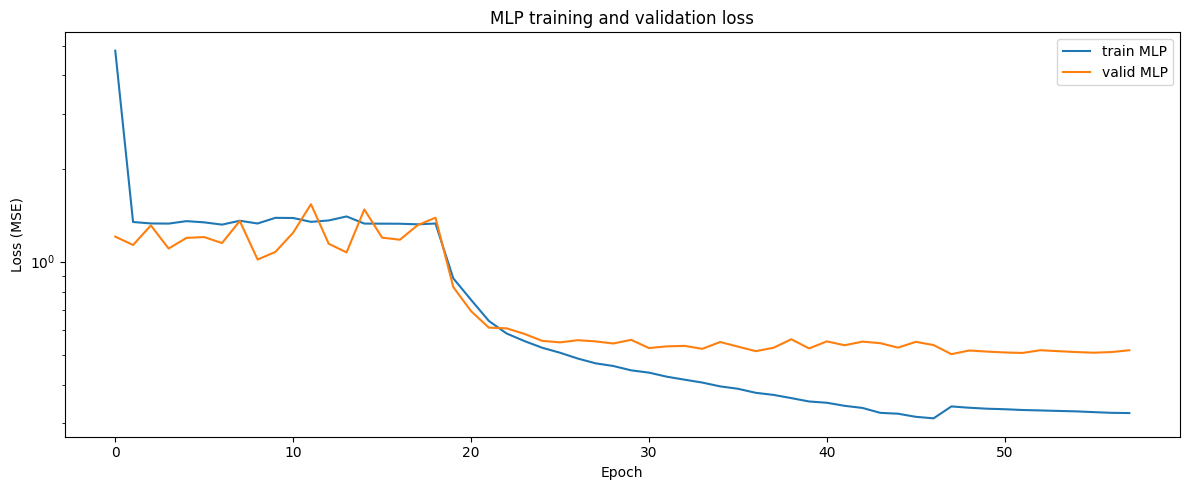

In [ ]:
# Evaluate MLP
preds_mlp_train = jax.vmap(model_mlp)(train_data_mlp['X'])
preds_mlp_valid = jax.vmap(model_mlp)(valid_data_mlp['X'])
preds_mlp_test  = jax.vmap(model_mlp)(test_data_mlp['X'])

preds_mlp_cf_train = scalerU.inverse_transform(preds_mlp_train)[:, :modes_cf] @ V_cf
preds_mlp_il_train = scalerU.inverse_transform(preds_mlp_train)[:, modes_cf:] @ V_il
preds_mlp_cf_valid = scalerU.inverse_transform(preds_mlp_valid)[:, :modes_cf] @ V_cf
preds_mlp_il_valid = scalerU.inverse_transform(preds_mlp_valid)[:, modes_cf:] @ V_il
preds_mlp_cf_test  = scalerU.inverse_transform(preds_mlp_test)[:, :modes_cf] @ V_cf
preds_mlp_il_test  = scalerU.inverse_transform(preds_mlp_test)[:, modes_cf:] @ V_il

print(f"{'='*60}")
print(f"MLP Reconstruction Errors")
print(f"{'='*60}")
print(f"Train  CF: {rmsre(preds_mlp_cf_train, Y_cf_train)*100:.2f}%  |  IL: {rmsre(preds_mlp_il_train, Y_il_train)*100:.2f}%")
print(f"Valid  CF: {rmsre(preds_mlp_cf_valid, Y_cf_valid)*100:.2f}%  |  IL: {rmsre(preds_mlp_il_valid, Y_il_valid)*100:.2f}%")
print(f"Test   CF: {rmsre(preds_mlp_cf_test,  Y_cf_test )*100:.2f}%  |  IL: {rmsre(preds_mlp_il_test,  Y_il_test )*100:.2f}%")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(train_losses_mlp_all, label='train MLP')
ax.plot(valid_losses_mlp_all, label='valid MLP')
ax.set_yscale('log')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (MSE)')
ax.set_title('MLP training and validation loss')
ax.legend()
plt.tight_layout()
plt.show()


## SHRED-Attention Baseline

Multi-head self-attention variant of SHRED: replaces LSTM layers with stacked attention layers.

In [ ]:
# SHREDAttention uses the same data dict as SHRED  (S_i, Y)
model_key_attn = jr.PRNGKey(13)
output_size_attn = train_data_shred['Y'].shape[-1]
print(f"Attention input_size={2*nsensors}, output_size={output_size_attn}")

model_attn = SHREDAttention(
    input_size           = 2 * nsensors,
    output_size          = output_size_attn,
    hidden_size          = 64,
    num_attention_layers = 2,
    num_heads            = 4,
    decoder_sizes        = [128, 256],
    activation           = jax.nn.tanh,
    use_layer_norm       = True,
    key                  = model_key_attn,
)
attn_params = count_parameters(model_attn)
print(f"SHREDAttention parameters: {attn_params:,}")


Attention input_size=6, output_size=29
SHREDAttention parameters: 87,455


In [ ]:
# Train SHREDAttention (multi-stage lr decay, same schedule as SHRED)
model_attn, train_losses_attn, valid_losses_attn = fit_SHRED_Attention(
    model_attn, train_data_shred, valid_data_shred,
    epochs=200, batch_size=64, lr=1e-2, early_stopping=10,
)
model_attn, train_losses_attn2, valid_losses_attn2 = fit_SHRED_Attention(
    model_attn, train_data_shred, valid_data_shred,
    epochs=200, batch_size=64, lr=1e-3, early_stopping=10,
)
model_attn, train_losses_attn3, valid_losses_attn3 = fit_SHRED_Attention(
    model_attn, train_data_shred, valid_data_shred,
    epochs=200, batch_size=64, lr=1e-4, early_stopping=10,
)

train_losses_attn_all = train_losses_attn + train_losses_attn2 + train_losses_attn3
valid_losses_attn_all = valid_losses_attn + valid_losses_attn2 + valid_losses_attn3
print(f"Total SHREDAttention epochs: {len(train_losses_attn_all)}")


Epoch  29/200 | Train 2.4656e-01 | Valid 5.3253e-01 | Time 0.47s | Patience 9/10
Early stopping at epoch 29, best validation loss: 5.0519e-01
Epoch  11/200 | Train 2.8398e-01 | Valid 5.3187e-01 | Time 0.46s | Patience 9/10
Early stopping at epoch 11, best validation loss: 5.1364e-01
Epoch  11/200 | Train 3.9063e-01 | Valid 5.1721e-01 | Time 0.45s | Patience 9/10
Early stopping at epoch 11, best validation loss: 5.0349e-01
Total SHREDAttention epochs: 51


SHREDAttention Reconstruction Errors
Train  CF: 39.25%  |  IL: 65.86%
Valid  CF: 55.15%  |  IL: 66.79%
Test   CF: 58.26%  |  IL: 75.95%


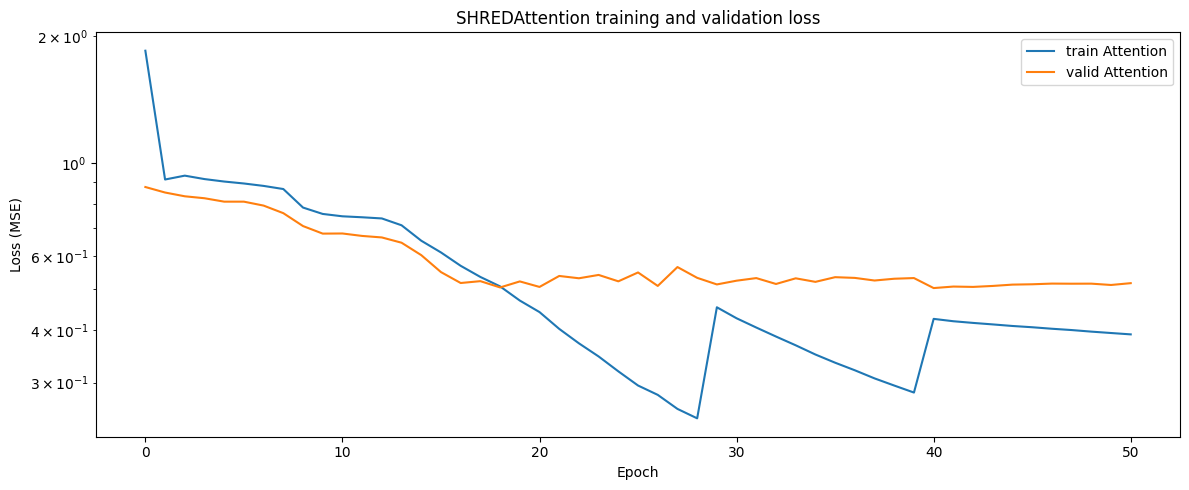

In [ ]:
# Evaluate SHREDAttention
preds_attn_train = jax.vmap(model_attn)(train_data_shred['S_i'])
preds_attn_valid = jax.vmap(model_attn)(valid_data_shred['S_i'])
preds_attn_test  = jax.vmap(model_attn)(test_data_shred['S_i'])

preds_attn_cf_train = scalerU.inverse_transform(preds_attn_train)[:, :modes_cf] @ V_cf
preds_attn_il_train = scalerU.inverse_transform(preds_attn_train)[:, modes_cf:] @ V_il
preds_attn_cf_valid = scalerU.inverse_transform(preds_attn_valid)[:, :modes_cf] @ V_cf
preds_attn_il_valid = scalerU.inverse_transform(preds_attn_valid)[:, modes_cf:] @ V_il
preds_attn_cf_test  = scalerU.inverse_transform(preds_attn_test)[:, :modes_cf] @ V_cf
preds_attn_il_test  = scalerU.inverse_transform(preds_attn_test)[:, modes_cf:] @ V_il

print(f"{'='*60}")
print(f"SHREDAttention Reconstruction Errors")
print(f"{'='*60}")
print(f"Train  CF: {rmsre(preds_attn_cf_train, Y_cf_train)*100:.2f}%  |  IL: {rmsre(preds_attn_il_train, Y_il_train)*100:.2f}%")
print(f"Valid  CF: {rmsre(preds_attn_cf_valid, Y_cf_valid)*100:.2f}%  |  IL: {rmsre(preds_attn_il_valid, Y_il_valid)*100:.2f}%")
print(f"Test   CF: {rmsre(preds_attn_cf_test,  Y_cf_test )*100:.2f}%  |  IL: {rmsre(preds_attn_il_test,  Y_il_test )*100:.2f}%")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(train_losses_attn_all, label='train Attention')
ax.plot(valid_losses_attn_all, label='valid Attention')
ax.set_yscale('log')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (MSE)')
ax.set_title('SHREDAttention training and validation loss')
ax.legend()
plt.tight_layout()
plt.show()


## All-model comparison

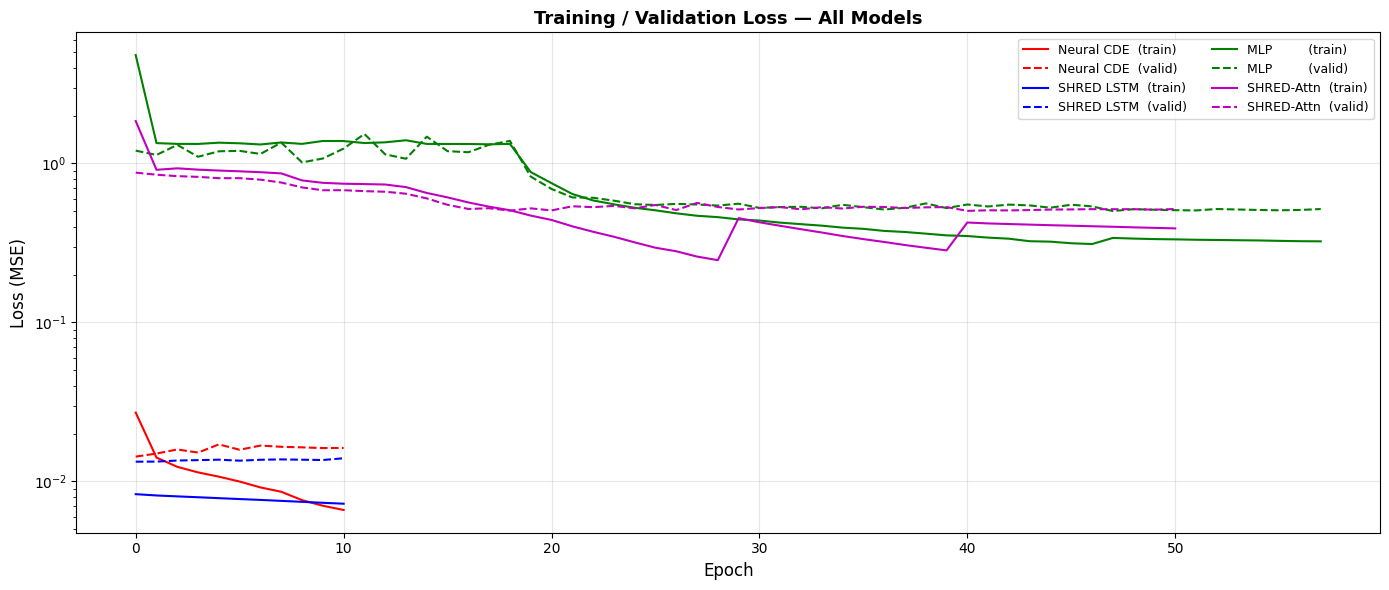


Model               Train CF  Train IL  Valid CF  Valid IL   Test CF   Test IL
--------------------------------------------------------------------------
Neural CDE            50.79%    73.00%    55.11%    68.69%    54.95%    71.60%
SHRED LSTM            30.14%    55.46%    52.93%    62.90%    58.62%    74.16%
MLP                   32.58%    57.77%    52.69%    74.22%    55.90%    75.24%
SHRED-Attention       39.25%    65.86%    55.15%    66.79%    58.26%    75.95%


In [ ]:
# ── Loss curves for all four models ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(train_losses_cde,        'r-',  lw=1.5, label='Neural CDE  (train)')
ax.plot(valid_losses_cde,        'r--', lw=1.5, label='Neural CDE  (valid)')
ax.plot(train_losses_shred,      'b-',  lw=1.5, label='SHRED LSTM  (train)')
ax.plot(valid_losses_shred,      'b--', lw=1.5, label='SHRED LSTM  (valid)')
ax.plot(train_losses_mlp_all,    'g-',  lw=1.5, label='MLP         (train)')
ax.plot(valid_losses_mlp_all,    'g--', lw=1.5, label='MLP         (valid)')
ax.plot(train_losses_attn_all,   'm-',  lw=1.5, label='SHRED-Attn  (train)')
ax.plot(valid_losses_attn_all,   'm--', lw=1.5, label='SHRED-Attn  (valid)')

ax.set_yscale('log')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss (MSE)', fontsize=12)
ax.set_title('Training / Validation Loss — All Models', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── RMSRE summary table ───────────────────────────────────────────────────────
print(f"\n{'='*74}")
print(f"{'Model':<18} {'Train CF':>9} {'Train IL':>9} {'Valid CF':>9} {'Valid IL':>9} {'Test CF':>9} {'Test IL':>9}")
print(f"{'-'*74}")

rows = [
    ("Neural CDE",
     preds_cde_cf_train,  preds_cde_il_train,
     preds_cde_cf_valid,  preds_cde_il_valid,
     preds_cde_cf_test,   preds_cde_il_test),
    ("SHRED LSTM",
     preds_shred_cf_train, preds_shred_il_train,
     preds_shred_cf_valid, preds_shred_il_valid,
     preds_shred_cf_test,  preds_shred_il_test),
    ("MLP",
     preds_mlp_cf_train,  preds_mlp_il_train,
     preds_mlp_cf_valid,  preds_mlp_il_valid,
     preds_mlp_cf_test,   preds_mlp_il_test),
    ("SHRED-Attention",
     preds_attn_cf_train, preds_attn_il_train,
     preds_attn_cf_valid, preds_attn_il_valid,
     preds_attn_cf_test,  preds_attn_il_test),
]

gt = [(Y_cf_train, Y_il_train), (Y_cf_valid, Y_il_valid), (Y_cf_test, Y_il_test)]

for name, pcft, pilt, pcfv, pilv, pcfte, pilte in rows:
    tcf  = rmsre(pcft,  Y_cf_train) * 100
    til  = rmsre(pilt,  Y_il_train) * 100
    vcf  = rmsre(pcfv,  Y_cf_valid) * 100
    vil  = rmsre(pilv,  Y_il_valid) * 100
    tecf = rmsre(pcfte, Y_cf_test ) * 100
    teil = rmsre(pilte, Y_il_test ) * 100
    print(f"{name:<18} {tcf:>8.2f}% {til:>8.2f}% {vcf:>8.2f}% {vil:>8.2f}% {tecf:>8.2f}% {teil:>8.2f}%")

print(f"{'='*74}")
